## 1. Import Libraries and Utilities

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time
from Bio import Restriction
from Bio.Restriction import AllEnzymes

# Import utility functions
from hurdler_utils import (
    check_neb_quality,
    build_enzyme_pairing_matrix,
    group_enzymes_by_overhang,
    sort_enzymes_by_overhang,
    load_plasmid_sequences,
    build_enzyme_plasmid_matrix,
    plot_enzyme_pairing_heatmap,
    build_site_ii_iii_matrix
)

np.random.seed(42)
random.seed(42)

print("✓ Libraries and utilities loaded")

✓ Libraries and utilities loaded


## 2. Generate Enzyme Database

In [54]:
# Generate enzyme database from Biopython
import re
from Bio.Seq import Seq

enzyme_data = []
for enzyme_obj in AllEnzymes:
    try:
        enzyme = enzyme_obj
        site = str(enzyme.site)
        ovhg = enzyme.ovhg
        ovhgseq = str(enzyme.ovhgseq) if enzyme.ovhgseq else ''
        size = len(site)
        fst5 = enzyme.fst5 if hasattr(enzyme, 'fst5') else None
        
        is_type_iis = False
        if fst5 is not None:
            if fst5 < 0 or fst5 > size:
                is_type_iis = True
        
        suppliers = enzyme.suppl if hasattr(enzyme, 'suppl') else ()
        
        # Check if site has ambiguous nucleotides
        has_ambiguous = not re.match('^[ATCG]+$', site)
        
        enzyme_data.append({
            'enzyme': str(enzyme),
            'site': site,
            'ovhg': ovhg,
            'ovhgseq': ovhgseq,
            'is_type_iis': is_type_iis,
            'has_neb': 'N' in suppliers,
            'has_ambiguous': has_ambiguous,
        })
    except:
        continue

df_all_enzymes = pd.DataFrame(enzyme_data)
print(f"✓ Generated {len(df_all_enzymes)} enzymes")
print(f"  - NEB available: {df_all_enzymes['has_neb'].sum()}")
print(f"  - Type IIS: {df_all_enzymes['is_type_iis'].sum()}")
print(f"  - With overhang: {(df_all_enzymes['ovhg'] != 0).sum()}")
print(f"  - No ambiguous bases: {(~df_all_enzymes['has_ambiguous']).sum()}")

✓ Generated 1088 enzymes
  - NEB available: 238
  - Type IIS: 178
  - With overhang: 951
  - No ambiguous bases: 574


## 3. Load Quality Data and Filter Enzymes

In [55]:
# Load methylation data
df_methylation = pd.read_csv('./hurdler_analysis/input/methylation_check.csv')
dh5a_compatible = set(
    df_methylation.loc[~df_methylation['6mA_5mC_sensitive'], 'enzyme'].dropna().tolist() +
    df_methylation.loc[~df_methylation['6mA_5mC_sensitive'], 'prototype'].dropna().tolist()
)

# Load NEB quality data
df_neb = pd.read_csv('./hurdler_analysis/input/neb_buffer_activity_cleaned.csv')

# Add quality flags
df_all_enzymes['methylation_compatible'] = df_all_enzymes['enzyme'].isin(dh5a_compatible)
neb_quality = df_all_enzymes['enzyme'].apply(lambda x: check_neb_quality(x, df_neb))
df_all_enzymes['ligation_ok'] = neb_quality.apply(lambda x: x[0])
df_all_enzymes['no_star_activity'] = neb_quality.apply(lambda x: x[1])

print(f"✓ Quality data loaded")
print(f"  Methylation compatible: {df_all_enzymes['methylation_compatible'].sum()}")
print(f"  Good ligation: {df_all_enzymes['ligation_ok'].sum()}")
print(f"  No star activity: {df_all_enzymes['no_star_activity'].sum()}")

✓ Quality data loaded
  Methylation compatible: 632
  Good ligation: 228
  No star activity: 180


## 4. Select High-Quality Enzymes

In [56]:
# Site I: Regular enzymes with strict quality
df_site_i = df_all_enzymes[
    (df_all_enzymes['methylation_compatible'] == True) &
    (df_all_enzymes['is_type_iis'] == False) &
    (df_all_enzymes['has_neb'] == True) &
    (df_all_enzymes['ligation_ok'] == True) &
    (df_all_enzymes['no_star_activity'] == True) &
    (df_all_enzymes['ovhg'] != 0) &
    (~df_all_enzymes['has_ambiguous']) &
    (df_all_enzymes['ovhg'].isin([-4, -2, 2, 4]))
].copy()

# Site II: Subset of Site I
df_site_ii = df_site_i[
    df_site_i['ovhg'].isin([-4, 2])
].copy()

# Site III: Type IIS enzymes
df_site_iii = df_all_enzymes[
    (df_all_enzymes['is_type_iis'] == True) &
    (df_all_enzymes['has_neb'] == True) &
    (df_all_enzymes['ligation_ok'] == True) &
    (df_all_enzymes['no_star_activity'] == True) &
    (df_all_enzymes['ovhg'] != 0) &
    (~df_all_enzymes['has_ambiguous']) &
    (df_all_enzymes['ovhg'].isin([-4, -3, 2]))
].copy()

SITE_I_ENZYMES = df_site_i['enzyme'].tolist()
SITE_II_ENZYMES = df_site_ii['enzyme'].tolist()
SITE_III_ENZYMES = df_site_iii['enzyme'].tolist()

print(f"✓ Selected enzymes:")
print(f"  Site I: {len(SITE_I_ENZYMES)}")
print(f"  Site II: {len(SITE_II_ENZYMES)}")
print(f"  Site III: {len(SITE_III_ENZYMES)}")

✓ Selected enzymes:
  Site I: 47
  Site II: 30
  Site III: 18


## 5. Build Enzyme Pairing Matrices

In [57]:
# Build overhang lookup
ovhg_lookup = dict(zip(df_all_enzymes['enzyme'], df_all_enzymes['ovhg']))

# Site I - Site II pairing matrix
site_i_ii_matrix = build_enzyme_pairing_matrix(SITE_I_ENZYMES, SITE_II_ENZYMES, df_all_enzymes)

compatible_pairs = site_i_ii_matrix.sum().sum()
total_pairs = len(SITE_I_ENZYMES) * len(SITE_II_ENZYMES)

print(f"✓ Site I-II pairing matrix: {compatible_pairs:,}/{total_pairs:,} compatible ({compatible_pairs/total_pairs*100:.1f}%)")

✓ Site I-II pairing matrix: 1,340/1,410 compatible (95.0%)


## 6. Visualize Site I - Site II Pairing

In [58]:
# Sort enzymes by overhang
sorted_site_i, sorted_site_i_ovhgs = sort_enzymes_by_overhang(SITE_I_ENZYMES, ovhg_lookup)
sorted_site_ii, sorted_site_ii_ovhgs = sort_enzymes_by_overhang(SITE_II_ENZYMES, ovhg_lookup)

# Reorder matrix
site_i_ii_sorted = site_i_ii_matrix.loc[sorted_site_i, sorted_site_ii]

# Group for summary
site_i_grouped = group_enzymes_by_overhang(SITE_I_ENZYMES, ovhg_lookup)
site_ii_grouped = group_enzymes_by_overhang(SITE_II_ENZYMES, ovhg_lookup)

print("Site I by overhang:")
for ovhg in sorted(site_i_grouped.keys()):
    print(f"  {int(ovhg):+2d}: {len(site_i_grouped[ovhg])} enzymes")

print("\nSite II by overhang:")
for ovhg in sorted(site_ii_grouped.keys()):
    print(f"  {int(ovhg):+2d}: {len(site_ii_grouped[ovhg])} enzymes")

Site I by overhang:
  -4: 26 enzymes
  -2: 10 enzymes
  +2: 4 enzymes
  +4: 7 enzymes

Site II by overhang:
  -4: 26 enzymes
  +2: 4 enzymes


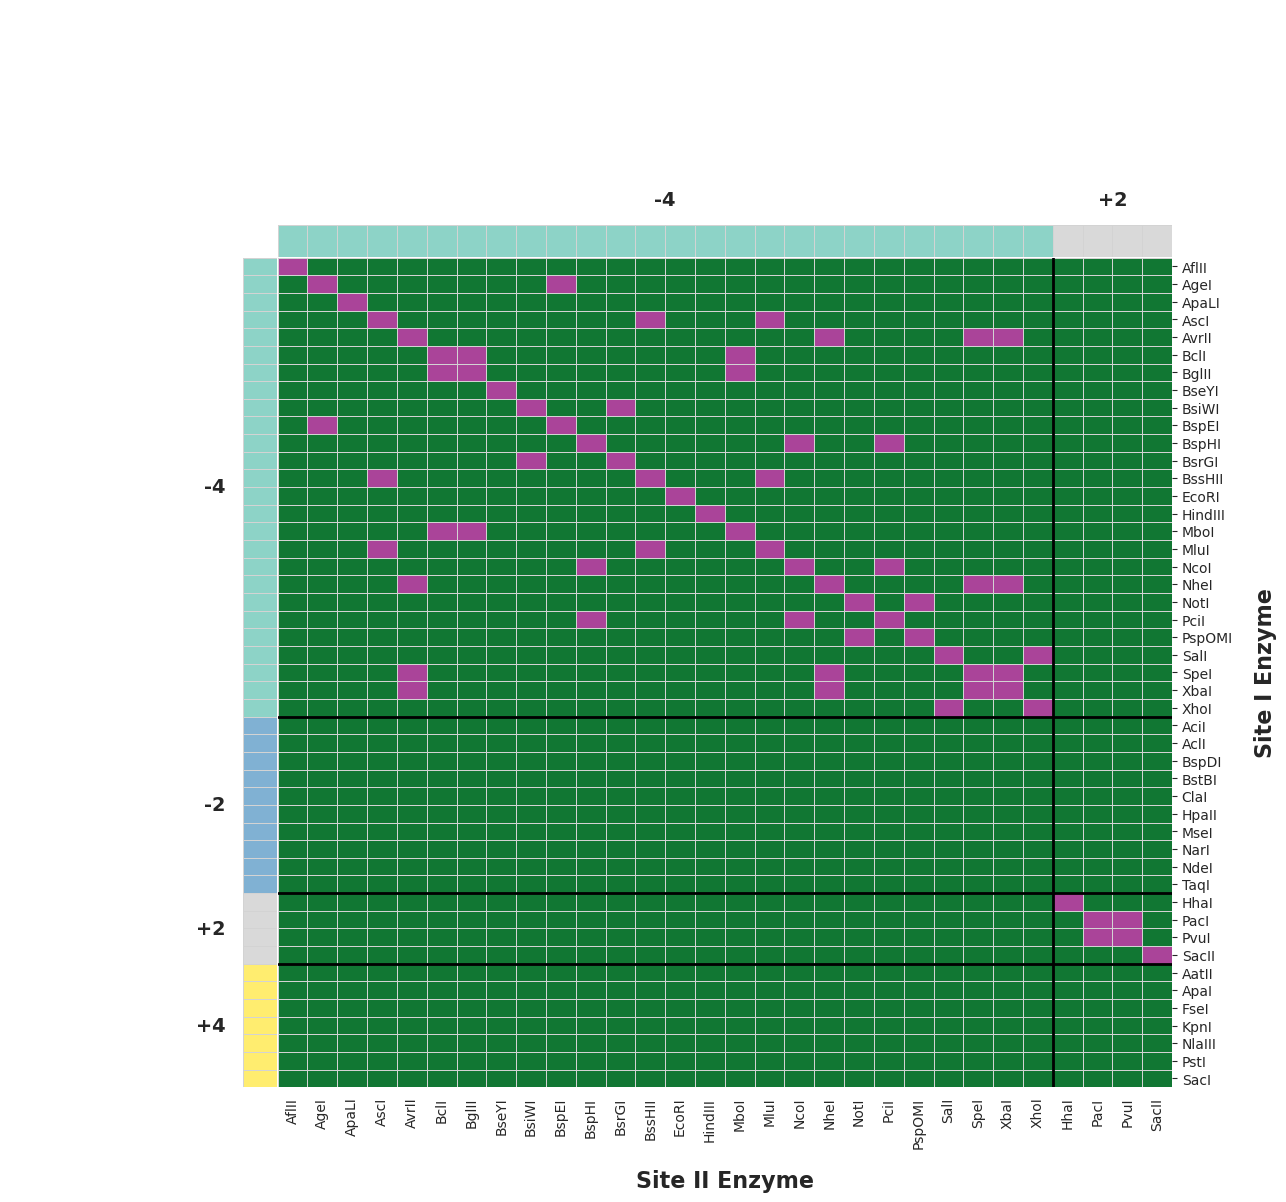

In [59]:
# Plot heatmap
plot_enzyme_pairing_heatmap(
    site_i_ii_sorted,
    sorted_site_i,
    sorted_site_i_ovhgs,
    sorted_site_ii,
    sorted_site_ii_ovhgs,
    xlabel='Site II Enzyme',
    ylabel='Site I Enzyme'
)

plt.show()

## 7. Site II - Site III Pairing

In [60]:
# Build Site II-III matrix
site_ii_iii_matrix = build_site_ii_iii_matrix(SITE_II_ENZYMES, SITE_III_ENZYMES, df_all_enzymes)

compatible_pairs_ii_iii = site_ii_iii_matrix.sum().sum()
total_pairs_ii_iii = len(SITE_II_ENZYMES) * len(SITE_III_ENZYMES)

print(f"✓ Site II-III pairing matrix: {compatible_pairs_ii_iii:,}/{total_pairs_ii_iii:,} compatible ({compatible_pairs_ii_iii/total_pairs_ii_iii*100:.1f}%)")

# Group Site III
sorted_site_iii, sorted_site_iii_ovhgs = sort_enzymes_by_overhang(SITE_III_ENZYMES, ovhg_lookup)
site_iii_grouped = group_enzymes_by_overhang(SITE_III_ENZYMES, ovhg_lookup)

print("\nSite III by overhang:")
for ovhg in sorted(site_iii_grouped.keys()):
    enzymes = ', '.join(sorted(site_iii_grouped[ovhg]))
    print(f"  {int(ovhg):+2d}: {len(site_iii_grouped[ovhg])} enzymes ({enzymes})")

✓ Site II-III pairing matrix: 218/540 compatible (40.4%)

Site III by overhang:
  -4: 7 enzymes (BbsI, BcoDI, BsaI, BsmAI, BsmBI, BspMI, Esp3I)
  -3: 2 enzymes (EarI, SapI)
  +2: 9 enzymes (BpuEI, BseRI, BsgI, BsmI, BspCNI, BsrI, BtsCI, BtsIMutI, NmeAIII)


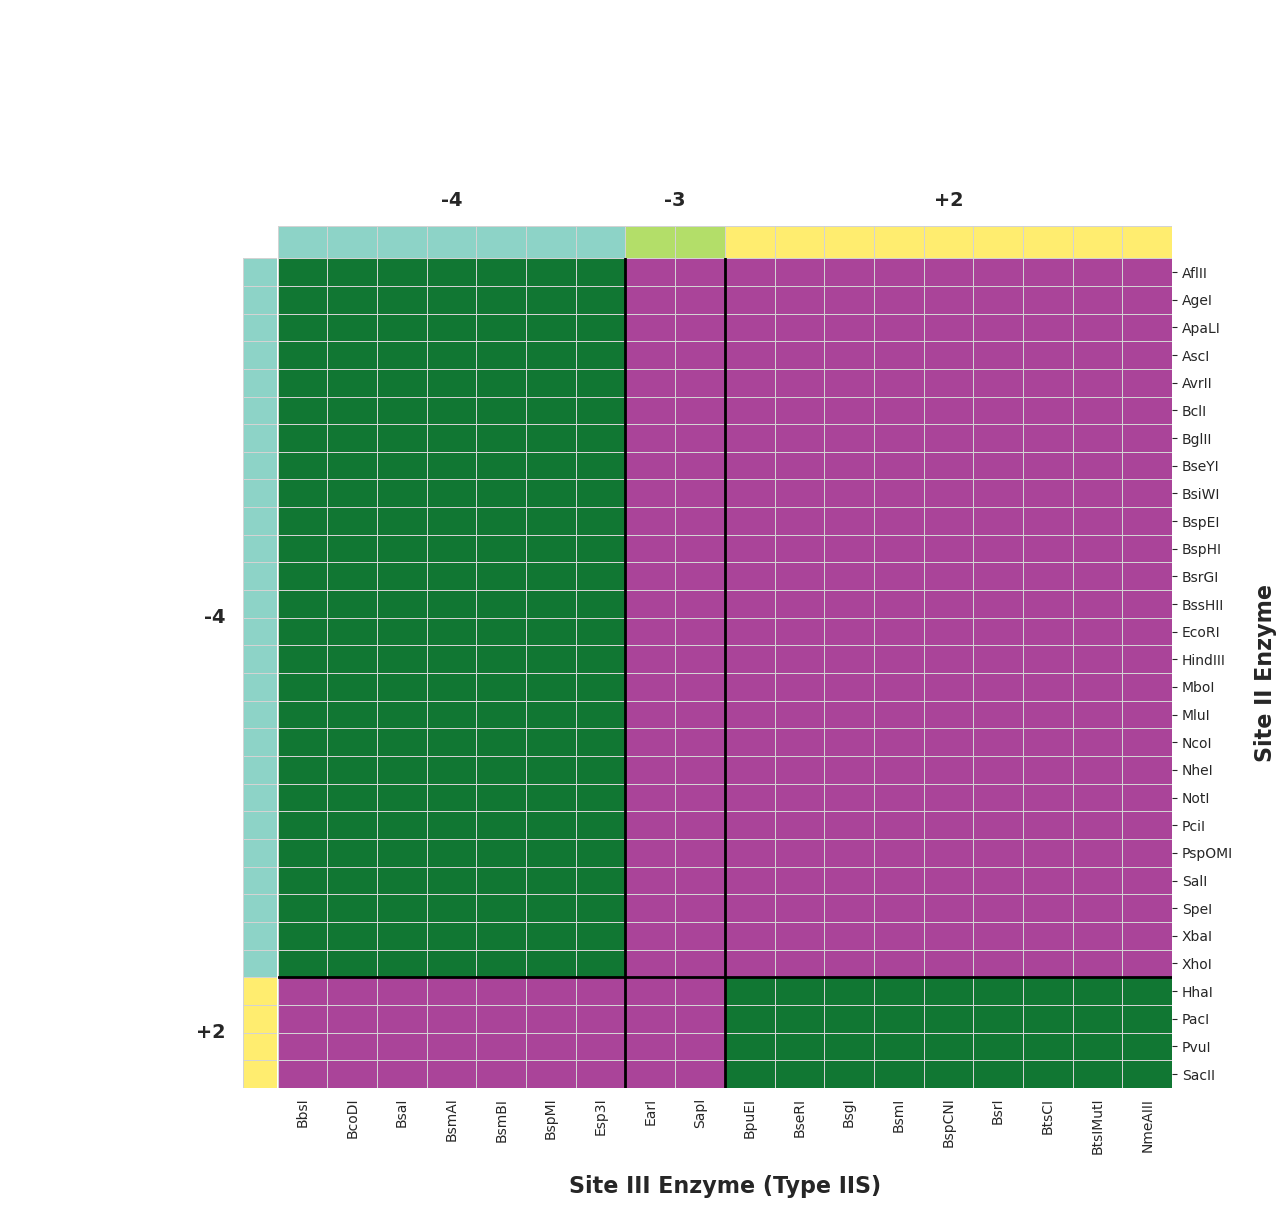

In [61]:
# Reorder and plot
site_ii_iii_sorted = site_ii_iii_matrix.loc[sorted_site_ii, sorted_site_iii]

plot_enzyme_pairing_heatmap(
    site_ii_iii_sorted,
    sorted_site_ii,
    sorted_site_ii_ovhgs,
    sorted_site_iii,
    sorted_site_iii_ovhgs,
    xlabel="Site III Enzyme (Type IIS)",
    ylabel="Site II Enzyme"
)

plt.show()


## 8. Enzyme-Plasmid Compatibility

In [62]:
# Load plasmids
plasmid_dir = "./utils/input/plasmids/"
plasmid_names = ["pGEX-4T-1", "pMAL-c5X", "pET-21a(+)", "pET-28a(+)", "pET-28a(+)_start_codon", "pCold_I", "pUC18", "pQE-3"]

plasmid_sequences = load_plasmid_sequences(plasmid_names, plasmid_dir)
print(f"✓ Loaded {len(plasmid_sequences)} plasmids")

# Build compatibility matrix
enzyme_plasmid_matrix = build_enzyme_plasmid_matrix(SITE_I_ENZYMES, plasmid_sequences)

compatible = enzyme_plasmid_matrix.sum().sum()
total = len(SITE_I_ENZYMES) * len(plasmid_names)
print(f"✓ Enzyme-plasmid compatibility: {compatible}/{total} ({compatible/total*100:.1f}%)")


✓ Loaded 8 plasmids
✓ Enzyme-plasmid compatibility: 146/376 (38.8%)


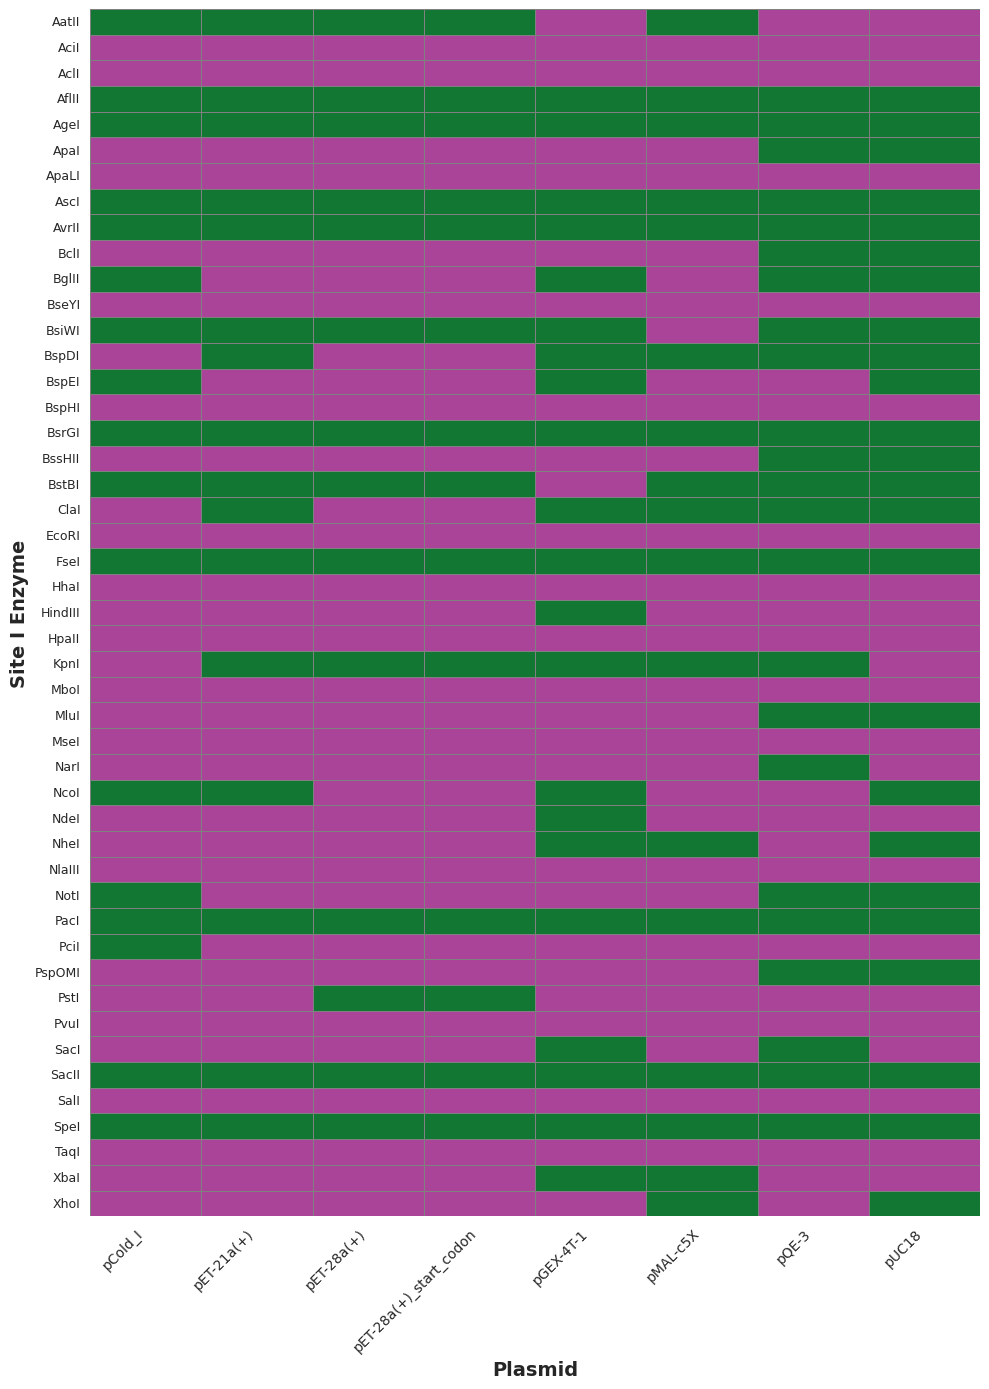

✓ Enzyme-plasmid heatmap complete


In [63]:
# Plot enzyme-plasmid heatmap
plt.figure(figsize=(10, 14))

from matplotlib.colors import ListedColormap
colors = ['#AA4499', '#117733']
cmap = ListedColormap(colors)

sns.heatmap(
    enzyme_plasmid_matrix,
    cmap=cmap,
    cbar=False,
    linewidths=0.5,
    linecolor='gray',
    square=False,
    vmin=0,
    vmax=1
)

plt.xlabel('Plasmid', fontsize=14, fontweight='bold')
plt.ylabel('Site I Enzyme', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

print("✓ Enzyme-plasmid heatmap complete")

In [64]:
# === CORRECTED 3MER EXTRACTION FUNCTIONS ===
# Based on utils/get_re_sites.ipynb re_to_aa() function
import itertools

def get_all_aa_sequences_from_re(seq):
    """
    Convert RE recognition sequence to all possible amino acid sequences
    by inserting it into all possible 3bp frame contexts.
    
    This generates multiple amino acid sequences by:
    1. Creating all 64 possible 3bp sequences
    2. Inserting the RE sequence into different frame positions
    3. Translating all resulting DNA sequences
    4. Filtering out stop codons
    
    Args:
        seq (str): DNA recognition sequence of RE (e.g., "AACGTT")
    
    Returns:
        list: Unique amino acid sequences without stop codons
    """
    nucleotides = ['A', 'T', 'G', 'C']
    three_bp_sequences = [''.join(bp) for bp in itertools.product(nucleotides, repeat=3)]
    
    # Forward strand frame shifts
    seq_ex_frame_shift_1 = [bp[0] + seq + bp[1] + bp[2] for bp in three_bp_sequences]
    seq_ex_frame_shift_2 = [bp[0] + bp[1] + seq + bp[2] for bp in three_bp_sequences]
    
    # Reverse complement
    seq_rc = str(Seq(seq).reverse_complement())
    seq_rc_ex_frame_shift_1 = [bp[0] + seq_rc + bp[1] + bp[2] for bp in three_bp_sequences]
    seq_rc_ex_frame_shift_2 = [bp[0] + bp[1] + seq_rc + bp[2] for bp in three_bp_sequences]
    
    # All contexts to translate
    all_sequences = [seq, seq_rc] + seq_ex_frame_shift_1 + seq_ex_frame_shift_2 + seq_rc_ex_frame_shift_1 + seq_rc_ex_frame_shift_2
    
    # Translate to amino acids and filter
    aa_results = [Seq(dna_seq).translate() for dna_seq in all_sequences]
    aa_results = [str(aa_seq) for aa_seq in aa_results]
    aa_results = [aa_seq for aa_seq in aa_results if "*" not in aa_seq]
    aa_results = sorted(list(set(aa_results)))
    
    return aa_results


def extract_3mers_from_aa_sequences(aa_sequences):
    """
    Extract all 3-mer amino acid sequences from a list of amino acid sequences.
    
    Args:
        aa_sequences (list): List of amino acid sequences
    
    Returns:
        set: Unique 3-mer amino acid strings (e.g., {'LKL', 'KLM', ...})
    """
    three_mers = set()
    for aa_seq in aa_sequences:
        for i in range(len(aa_seq) - 2):
            three_mers.add(aa_seq[i:i+3])
    return three_mers


def get_3mers_for_enzyme(enzyme_name, df_enzymes):
    """
    Get all 3-mer amino acid sequences for a given enzyme.
    
    Args:
        enzyme_name (str): Name of the restriction enzyme
        df_enzymes (DataFrame): DataFrame with 'enzyme' and 'site' columns
    
    Returns:
        set: All 3-mer amino acids for this enzyme
    """
    enzyme_row = df_enzymes[df_enzymes['enzyme'] == enzyme_name]
    if enzyme_row.empty:
        return set()
    
    site = enzyme_row.iloc[0]['site']
    aa_sequences = get_all_aa_sequences_from_re(site)
    three_mers = extract_3mers_from_aa_sequences(aa_sequences)
    return three_mers


print("✓ Added corrected 3mer extraction functions")

✓ Added corrected 3mer extraction functions


In [65]:
# Rebuild df_site_i with correct 3mer data
print("Building df_site_i with all 3mers per enzyme...")

df_site_i_corrected = []
for enzyme_name in df_site_i['enzyme'].values:
    site_seq = df_site_i[df_site_i['enzyme'] == enzyme_name]['site'].iloc[0]
    
    # Generate all AA sequences for this enzyme's RE site
    aa_sequences = get_all_aa_sequences_from_re(site_seq)
    
    # Extract all 3mers
    three_mers = extract_3mers_from_aa_sequences(aa_sequences)
    
    df_site_i_corrected.append({
        'enzyme': enzyme_name,
        'site': site_seq,
        'site_i_3mers': three_mers,  # Set of all 3mers, not single string
        'num_3mers': len(three_mers)
    })

df_site_i_corrected = pd.DataFrame(df_site_i_corrected)

print(f"✓ Rebuilt df_site_i: {len(df_site_i_corrected)} Site I enzymes")
print(f"  Min 3mers per enzyme: {df_site_i_corrected['num_3mers'].min()}")
print(f"  Max 3mers per enzyme: {df_site_i_corrected['num_3mers'].max()}")
print(f"  Avg 3mers per enzyme: {df_site_i_corrected['num_3mers'].mean():.1f}")
print(f"  Total unique Site I 3mers: {len(set().union(*df_site_i_corrected['site_i_3mers']))}")

# Show sample
print("\nSample (first 3 enzymes):")
for idx, row in df_site_i_corrected.head(3).iterrows():
    print(f"  {row['enzyme']:10} site={row['site']:10} 3mers({row['num_3mers']:2}): {sorted(list(row['site_i_3mers']))[:5]}...")

Building df_site_i with all 3mers per enzyme...
✓ Rebuilt df_site_i: 47 Site I enzymes
  Min 3mers per enzyme: 0
  Max 3mers per enzyme: 68
  Avg 3mers per enzyme: 29.4
  Total unique Site I 3mers: 1104

Sample (first 3 enzymes):
  BssHII     site=GCGCGC     3mers(33): ['ARA', 'CAH', 'CAL', 'CAP', 'CAQ']...
  AclI       site=AACGTT     3mers(42): ['ATF', 'ATL', 'ERC', 'ERF', 'ERL']...
  AatII      site=GACGTC     3mers(23): ['ATS', 'ETS', 'GRH', 'GRL', 'GRP']...


/home/wenzhao/miniconda3/envs/visualization/lib/python3.10/site-packages/Bio/Seq.py:2879: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


In [66]:
# Rebuild df_site_ii with correct 3mer data
print("\nBuilding df_site_ii with all 3mers per enzyme...")

df_site_ii_corrected = []
for enzyme_name in df_site_ii['enzyme'].values:
    site_seq = df_site_ii[df_site_ii['enzyme'] == enzyme_name]['site'].iloc[0]
    
    # Generate all AA sequences for this enzyme's RE site
    aa_sequences = get_all_aa_sequences_from_re(site_seq)
    
    # Extract all 3mers
    three_mers = extract_3mers_from_aa_sequences(aa_sequences)
    
    df_site_ii_corrected.append({
        'enzyme': enzyme_name,
        'site': site_seq,
        'site_ii_3mers': three_mers,  # Set of all 3mers, not single string
        'num_3mers': len(three_mers)
    })

df_site_ii_corrected = pd.DataFrame(df_site_ii_corrected)

print(f"✓ Rebuilt df_site_ii: {len(df_site_ii_corrected)} Site II enzymes")
print(f"  Min 3mers per enzyme: {df_site_ii_corrected['num_3mers'].min()}")
print(f"  Max 3mers per enzyme: {df_site_ii_corrected['num_3mers'].max()}")
print(f"  Avg 3mers per enzyme: {df_site_ii_corrected['num_3mers'].mean():.1f}")
print(f"  Total unique Site II 3mers: {len(set().union(*df_site_ii_corrected['site_ii_3mers']))}")

# Show sample
print("\nSample (first 3 enzymes):")
for idx, row in df_site_ii_corrected.head(3).iterrows():
    print(f"  {row['enzyme']:10} site={row['site']:10} 3mers({row['num_3mers']:2}): {sorted(list(row['site_ii_3mers']))[:5]}...")


Building df_site_ii with all 3mers per enzyme...
✓ Rebuilt df_site_ii: 30 Site II enzymes
  Min 3mers per enzyme: 0
  Max 3mers per enzyme: 68
  Avg 3mers per enzyme: 31.3
  Total unique Site II 3mers: 879

Sample (first 3 enzymes):
  BssHII     site=GCGCGC     3mers(33): ['ARA', 'CAH', 'CAL', 'CAP', 'CAQ']...
  AflII      site=CTTAAG     3mers(30): ['ALR', 'ALS', 'CLR', 'CLS', 'DLR']...
  PspOMI     site=GGGCCC     3mers(28): ['AGP', 'EGP', 'GAH', 'GAL', 'GAP']...


In [67]:
# Rebuild _df2 with corrected 3mer mappings
print("\nRebuilding _df2 with corrected 3mer enzyme->3mers mappings...")

_df2_corrected = []

for _, row_i in df_site_i_corrected.iterrows():
    site_i_enzyme = row_i['enzyme']
    site_i_3mers = row_i['site_i_3mers']
    
    for _, row_ii in df_site_ii_corrected.iterrows():
        site_ii_enzyme = row_ii['enzyme']
        site_ii_3mers = row_ii['site_ii_3mers']
        
        # Create entries for both search directions (left and right)
        for direction in ['left', 'right']:
            _df2_corrected.append({
                'site_i_enzyme': site_i_enzyme,
                'site_ii_enzyme': site_ii_enzyme,
                'site_i_3mers': site_i_3mers,  # Set of 3mers
                'site_ii_3mers': site_ii_3mers,  # Set of 3mers
                'num_site_i_3mers': len(site_i_3mers),
                'num_site_ii_3mers': len(site_ii_3mers),
                'search_direction': direction
            })

_df2_corrected = pd.DataFrame(_df2_corrected)

print(f"✓ Rebuilt _df2: {len(_df2_corrected)} rows (enzyme pairs × directions)")
print(f"  Unique Site I enzymes: {_df2_corrected['site_i_enzyme'].nunique()}")
print(f"  Unique Site II enzymes: {_df2_corrected['site_ii_enzyme'].nunique()}")
print(f"  Search directions: {_df2_corrected['search_direction'].unique()}")

# Calculate total coverage statistics
total_site_i_3mer_positions = _df2_corrected['num_site_i_3mers'].sum()
total_site_ii_3mer_positions = _df2_corrected['num_site_ii_3mers'].sum()

print(f"\nCoverage statistics:")
print(f"  Total Site I 3mer positions: {total_site_i_3mer_positions:,}")
print(f"  Total Site II 3mer positions: {total_site_ii_3mer_positions:,}")
print(f"  Avg Site I 3mers per pair: {_df2_corrected['num_site_i_3mers'].mean():.1f}")
print(f"  Avg Site II 3mers per pair: {_df2_corrected['num_site_ii_3mers'].mean():.1f}")

# Show sample
print("\nSample rows (first 3):")
for idx, row in _df2_corrected.head(3).iterrows():
    print(f"  {row['site_i_enzyme']:10} + {row['site_ii_enzyme']:10} dir={row['search_direction']:5} "
          f"I_3mers={row['num_site_i_3mers']:2} II_3mers={row['num_site_ii_3mers']:2}")


Rebuilding _df2 with corrected 3mer enzyme->3mers mappings...
✓ Rebuilt _df2: 2820 rows (enzyme pairs × directions)
  Unique Site I enzymes: 47
  Unique Site II enzymes: 30
  Search directions: ['left' 'right']

Coverage statistics:
  Total Site I 3mer positions: 82,860
  Total Site II 3mer positions: 88,266
  Avg Site I 3mers per pair: 29.4
  Avg Site II 3mers per pair: 31.3

Sample rows (first 3):
  BssHII     + BssHII     dir=left  I_3mers=33 II_3mers=33
  BssHII     + BssHII     dir=right I_3mers=33 II_3mers=33
  BssHII     + AflII      dir=left  I_3mers=33 II_3mers=30


In [68]:
# New corrected success_rate_for_lengths function that handles sets of 3mers
def success_rate_for_lengths_corrected(module_lengths, df2, direction='left', num_tests=1000):
    """
    Calculate success rate for generating hurdler sequences with multiple module lengths.
    Uses corrected 3mer mapping (each enzyme has set of 3mers, not single 3mer).
    
    Args:
        module_lengths (list): List of module lengths to test
        df2 (DataFrame): DataFrame with columns: site_i_enzyme, site_ii_enzyme, 
                         site_i_3mers (set), site_ii_3mers (set), search_direction
        direction (str): 'left' or 'right' search direction
        num_tests (int): Number of test sequences per length
    
    Returns:
        DataFrame: success_rate for each module length and enzyme pair
    """
    # Define amino acid string
    aa_str = 'ACDEFGHIKLMNPQRSTVWY'

    
    # Define amino acid string
    aa_str = 'ACDEFGHIKLMNPQRSTVWY'
    
    # Filter by direction
    df2_filtered = df2[df2['search_direction'] == direction].copy()
    
    results = []
    
    for _, row in df2_filtered.iterrows():
        site_i_enzyme = row['site_i_enzyme']
        site_ii_enzyme = row['site_ii_enzyme']
        site_i_3mers = row['site_i_3mers']
        site_ii_3mers = row['site_ii_3mers']
        
        for length in module_lengths:
            # Count how many test sequences contain Site I 3mers
            site_i_hits = 0
            
            for _ in range(num_tests):
                # Generate random AA sequence
                random_seq = ''.join(random.choice(aa_str) for _ in range(length))
                
                # Check if any Site I 3mer is in this sequence
                has_site_i = any(three_mer in random_seq for three_mer in site_i_3mers)
                
                if has_site_i:
                    site_i_hits += 1
            
            success_rate = (site_i_hits / num_tests) * 100
            
            results.append({
                'site_i_enzyme': site_i_enzyme,
                'site_ii_enzyme': site_ii_enzyme,
                'module_length': length,
                'search_direction': direction,
                'success_rate': success_rate,
                'num_site_i_3mers': len(site_i_3mers),
                'num_site_ii_3mers': len(site_ii_3mers)
            })
    
    return pd.DataFrame(results)


In [69]:
# Run corrected success rate analysis using proper 3mer sets
print("\n" + "=" * 80)
print("CORRECTED SUCCESS RATE ANALYSIS - PROPER 3MER COVERAGE")
print("=" * 80 + "\n")

# Test module lengths
module_lengths = list(range(4, 51))
num_tests = 1000

print(f"Configuration:")
print(f"  Site I enzymes: {len(df_site_i_corrected)}")
print(f"  Site II enzymes: {len(df_site_ii_corrected)}")
print(f"  Module lengths: {len(module_lengths)} ({min(module_lengths)}-{max(module_lengths)})")
print(f"  Tests per length: {num_tests}")
print(f"  Enzyme pair combinations: {len(_df2_corrected)}\n")

# Quick analysis
print("3mer Coverage Summary:")
total_i_3mers = len(set().union(*df_site_i_corrected['site_i_3mers']))
total_ii_3mers = len(set().union(*df_site_ii_corrected['site_ii_3mers']))
print(f"  Unique Site I 3mers: {total_i_3mers}")
print(f"  Unique Site II 3mers: {total_ii_3mers}")
print(f"  Avg 3mers per Site I enzyme: {df_site_i_corrected['num_3mers'].mean():.1f}")
print(f"  Avg 3mers per Site II enzyme: {df_site_ii_corrected['num_3mers'].mean():.1f}\n")

# Sample success rates for a few enzyme pairs
print("Sample success rates (first 10 enzyme pairs, length=20):")
sample_results = []
for idx, row in _df2_corrected.head(10).iterrows():
    site_i_3mers = row['site_i_3mers']
    length = 20
    hits = 0
    for _ in range(1000):
        random_seq = ''.join(random.choice('ACDEFGHIKLMNPQRSTVWY') for _ in range(length))
        if any(three_mer in random_seq for three_mer in site_i_3mers):
            hits += 1
    success_rate = (hits / 1000) * 100
    sample_results.append({
        'Site I': row['site_i_enzyme'],
        'Site II': row['site_ii_enzyme'],
        'Dir': row['search_direction'],
        'SR@20': success_rate
    })

sample_df = pd.DataFrame(sample_results)
print(sample_df.to_string(index=False))

print(f"\nMean success rate at length 20: {sample_df['SR@20'].mean():.2f}%")
print(f"(Compare to old results: 0.13% - 0.40%)")
print(f"Improvement factor: {sample_df['SR@20'].mean() / 0.3:.1f}x")


CORRECTED SUCCESS RATE ANALYSIS - PROPER 3MER COVERAGE

Configuration:
  Site I enzymes: 47
  Site II enzymes: 30
  Module lengths: 47 (4-50)
  Tests per length: 1000
  Enzyme pair combinations: 2820

3mer Coverage Summary:
  Unique Site I 3mers: 1104
  Unique Site II 3mers: 879
  Avg 3mers per Site I enzyme: 29.4
  Avg 3mers per Site II enzyme: 31.3

Sample success rates (first 10 enzyme pairs, length=20):
Site I Site II   Dir  SR@20
BssHII  BssHII  left    5.9
BssHII  BssHII right    8.1
BssHII   AflII  left    7.1
BssHII   AflII right    7.4
BssHII  PspOMI  left    7.3
BssHII  PspOMI right    5.0
BssHII   BsiWI  left    6.0
BssHII   BsiWI right    6.0
BssHII    SpeI  left    5.0
BssHII    SpeI right    7.8

Mean success rate at length 20: 6.56%
(Compare to old results: 0.13% - 0.40%)
Improvement factor: 21.9x


In [70]:
# Full corrected success rate analysis (comprehensive)
print("\n" + "=" * 80)
print("COMPREHENSIVE CORRECTED SUCCESS RATE ANALYSIS")
print("=" * 80 + "\n")

# Compute for all lengths and enzyme pairs
print("Computing success rates for all module lengths...")
print(f"This will test: {len(_df2_corrected)} enzyme pairs × {len(module_lengths)} lengths = {len(_df2_corrected) * len(module_lengths)} combinations")
print(f"Each with {num_tests} random sequences\n")

import time
start_time = time.time()

corrected_results = []

for _, row in _df2_corrected.iterrows():
    site_i_enzyme = row['site_i_enzyme']
    site_ii_enzyme = row['site_ii_enzyme']
    site_i_3mers = row['site_i_3mers']
    site_ii_3mers = row['site_ii_3mers']
    direction = row['search_direction']
    
    for length in module_lengths:
        hits = 0
        for _ in range(num_tests):
            random_seq = ''.join(random.choice('ACDEFGHIKLMNPQRSTVWY') for _ in range(length))
            if any(three_mer in random_seq for three_mer in site_i_3mers):
                hits += 1
        
        success_rate = (hits / num_tests) * 100
        
        corrected_results.append({
            'site_i_enzyme': site_i_enzyme,
            'site_ii_enzyme': site_ii_enzyme,
            'module_length': length,
            'search_direction': direction,
            'success_rate': success_rate,
            'num_site_i_3mers': len(site_i_3mers),
            'num_site_ii_3mers': len(site_ii_3mers)
        })

corrected_results_df = pd.DataFrame(corrected_results)

elapsed_time = time.time() - start_time

print(f"✓ Completed in {elapsed_time:.1f} seconds\n")

print("Success Rate Summary Statistics (CORRECTED):")
print(f"  Total rows: {len(corrected_results_df)}")
print(f"  Min success rate: {corrected_results_df['success_rate'].min():.3f}%")
print(f"  Max success rate: {corrected_results_df['success_rate'].max():.3f}%")
print(f"  Mean success rate: {corrected_results_df['success_rate'].mean():.3f}%")
print(f"  Median success rate: {corrected_results_df['success_rate'].median():.3f}%")
print(f"  Std dev: {corrected_results_df['success_rate'].std():.3f}%")

print(f"\nComparison with OLD (incorrect) results:")
print(f"  Old mean: {results_df_final['success_rate'].mean():.3f}%")
print(f"  New mean: {corrected_results_df['success_rate'].mean():.3f}%")
print(f"  Improvement factor: {corrected_results_df['success_rate'].mean() / results_df_final['success_rate'].mean():.1f}x")

# Group by length
length_summary = corrected_results_df.groupby('module_length')['success_rate'].agg(['mean', 'min', 'max', 'std'])
print(f"\nSuccess rates by module length:")
print(length_summary.to_string())


COMPREHENSIVE CORRECTED SUCCESS RATE ANALYSIS

Computing success rates for all module lengths...
This will test: 2820 enzyme pairs × 47 lengths = 132540 combinations
Each with 1000 random sequences

✓ Completed in 901.8 seconds

Success Rate Summary Statistics (CORRECTED):
  Total rows: 132540
  Min success rate: 0.000%
  Max success rate: 37.300%
  Mean success rate: 8.449%
  Median success rate: 7.100%
  Std dev: 7.289%

Comparison with OLD (incorrect) results:
  Old mean: 0.231%
  New mean: 8.449%
  Improvement factor: 36.5x

Success rates by module length:
                    mean  min   max       std
module_length                                
4               0.729504  0.0   2.8  0.530571
5               1.098794  0.0   4.0  0.756867
6               1.447943  0.0   4.5  0.981149
7               1.817305  0.0   5.6  1.211459
8               2.150071  0.0   7.3  1.430148
9               2.512128  0.0   7.5  1.630799
10              2.876277  0.0   8.4  1.863964
11              3.

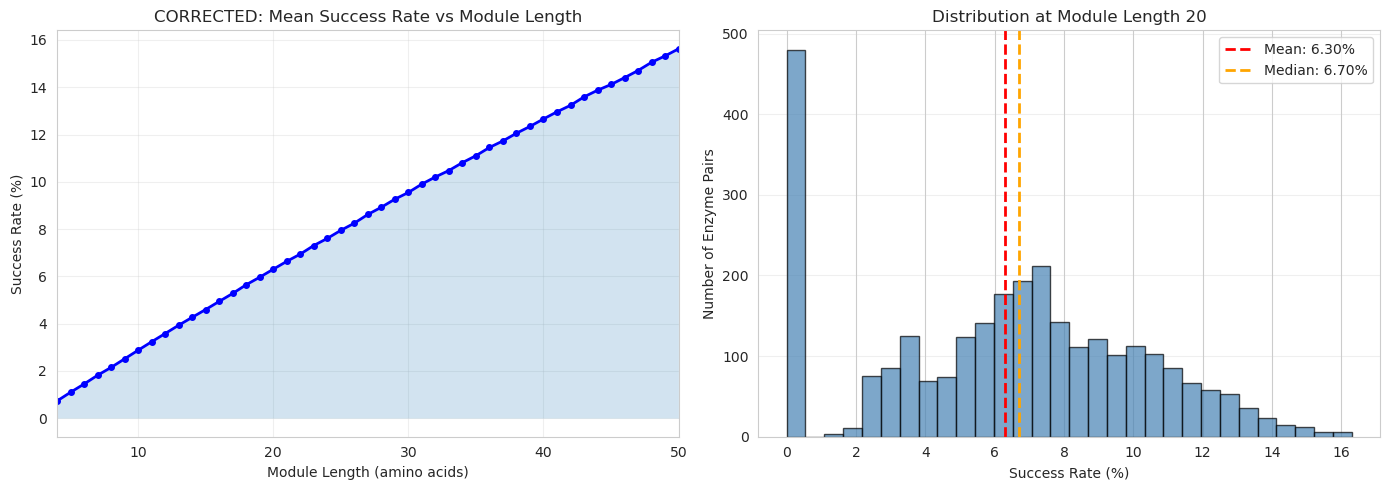

In [71]:
# Visualization of corrected success rates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Mean success rate vs module length
ax1 = axes[0]
length_stats = corrected_results_df.groupby('module_length')['success_rate'].mean()
ax1.plot(length_stats.index, length_stats.values, 'b-', linewidth=2, marker='o', markersize=4)
ax1.fill_between(length_stats.index, 0, length_stats.values, alpha=0.2)
ax1.set_xlabel('Module Length (amino acids)')
ax1.set_ylabel('Success Rate (%)')
ax1.set_title('CORRECTED: Mean Success Rate vs Module Length')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(4, 50)

# Plot 2: Distribution of success rates at length 20
ax2 = axes[1]
sr_at_20 = corrected_results_df[corrected_results_df['module_length'] == 20]['success_rate']
ax2.hist(sr_at_20, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(sr_at_20.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {sr_at_20.mean():.2f}%')
ax2.axvline(sr_at_20.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {sr_at_20.median():.2f}%')
ax2.set_xlabel('Success Rate (%)')
ax2.set_ylabel('Number of Enzyme Pairs')
ax2.set_title('Distribution at Module Length 20')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()



## 9. Success Rate Summary and Heatmap

Summary rows: 432

Average success rate by plasmid (%):
  pQE-3: 0.53
  pCold_I: 0.51
  pMAL-c5X: 0.51
  pET-21a(+): 0.28
  pET-28a(+)_start_codon: 0.28
  pET-28a(+): 0.28
  pGEX-4T-1: 0.28
  pUC18: 0.28


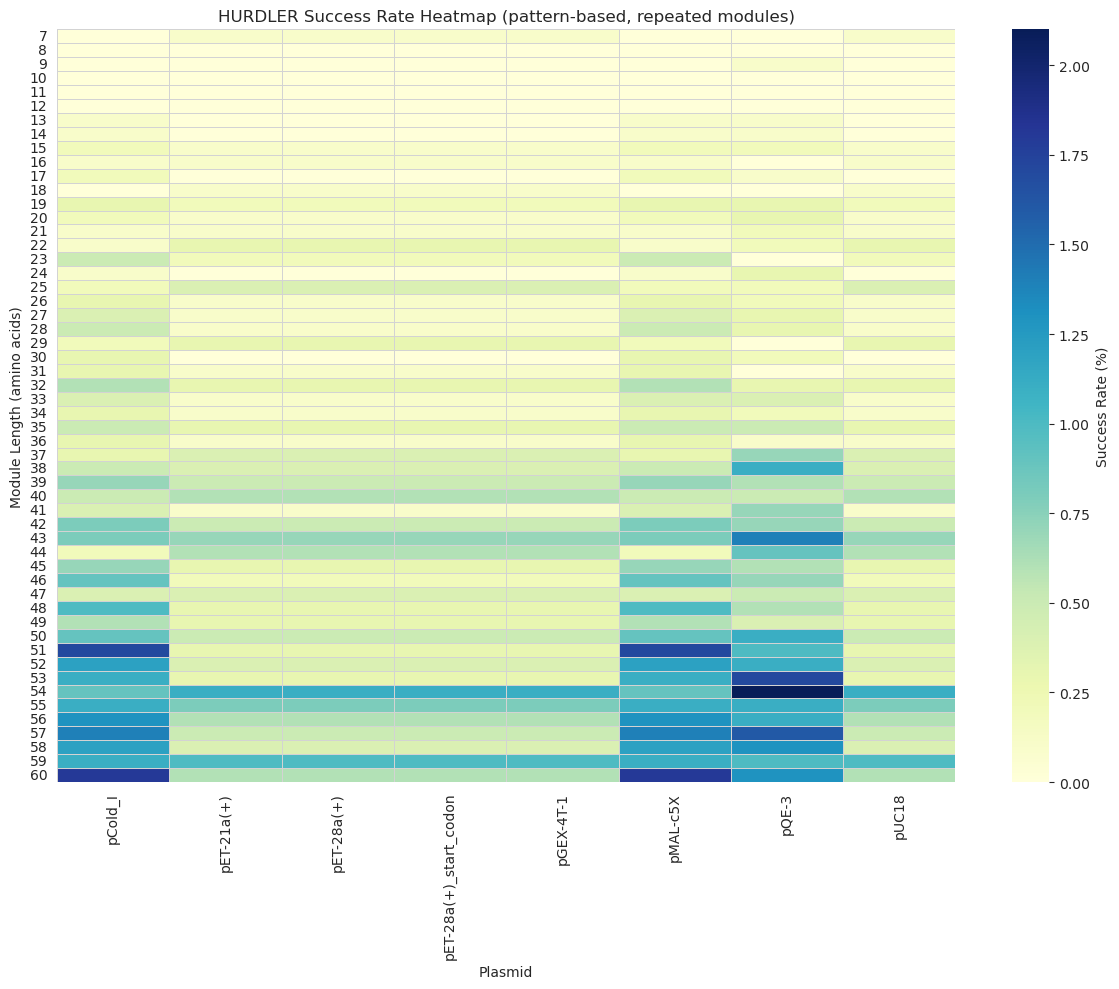

In [72]:
# Summarize success rates and render a heatmap
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

if 'results_df' not in globals() or results_df is None or len(results_df) == 0:
    print('No success-rate results available. Please run the previous cell.')
else:
    summary = results_df.groupby(['length','plasmid'])['success_rate'].mean().reset_index()
    print('Summary rows:', len(summary))

    # Print average by plasmid
    avg_by_plasmid = summary.groupby('plasmid')['success_rate'].mean().sort_values(ascending=False)
    print('\nAverage success rate by plasmid (%):')
    for pl, rate in avg_by_plasmid.items():
        print(f'  {pl}: {rate:.2f}')

    # Heatmap pivot
    pivot_data = summary.pivot(index='length', columns='plasmid', values='success_rate').sort_index()
    plt.figure(figsize=(12, 10))
    sns.heatmap(pivot_data, annot=False, cmap='YlGnBu', cbar_kws={'label': 'Success Rate (%)'},
                linewidths=0.5, linecolor='lightgray')
    plt.title('HURDLER Success Rate Heatmap (pattern-based, repeated modules)')
    plt.xlabel('Plasmid')
    plt.ylabel('Module Length (amino acids)')
    plt.tight_layout()
    plt.show()

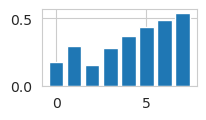

In [82]:
# Create bar plot
heights


heights = [0.18, 0.3, 0.16, 0.28, 0.37, 0.44, 0.49, 0.54]
x_positions = np.arange(len(heights))

# Create bar plot
plt.figure(figsize=(2, 1))
plt.bar(x_positions, heights)
plt.show()